## TASK -2 TITANIC SURVIVAL PREDICTION
## NAME: ANSHI SHARMA
## DOMAIN: DATA SCIENCE

In [34]:
# Importing the essential libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,recall_score
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import LabelEncoder


In [6]:
# reading the dataset
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
#information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
#descriptive statistics about dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## EDA AND VISUALIZATION

In [11]:
#DETECTING MISSING VALUES
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.drop(columns=['Cabin','PassengerId','Name','Ticket'],axis=1,inplace=True)

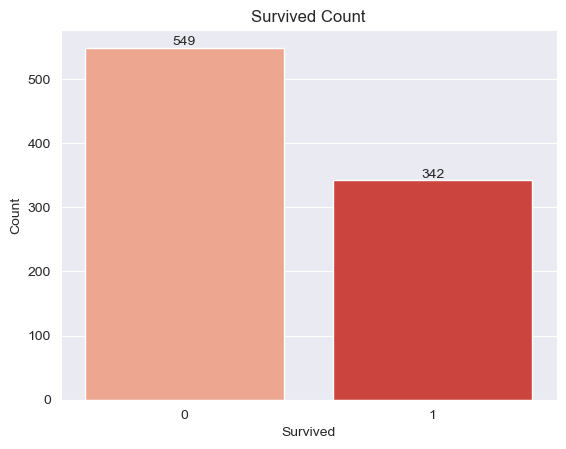

In [13]:
# survived calculations
g=sns.countplot(data=df,x='Survived',palette='Reds')
for i in g.containers:
    g.bar_label(i)
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title('Survived Count')
plt.show()

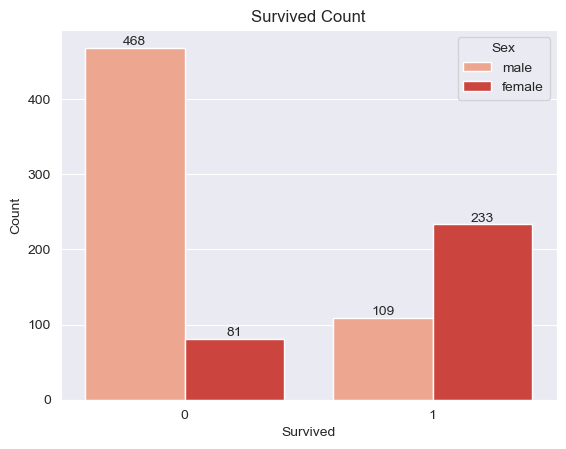

In [14]:
#survived are of which sex
g=sns.countplot(data=df,x='Survived',hue='Sex',palette='Reds')
for i in g.containers:
    g.bar_label(i)
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title('Survived Count')
plt.show()

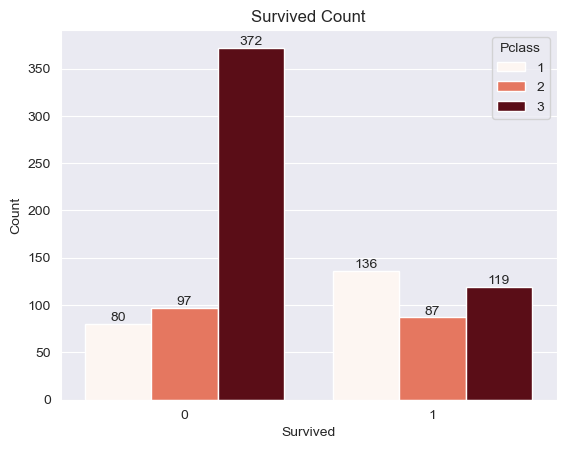

In [15]:
g=sns.countplot(data=df,x='Survived',hue='Pclass',palette='Reds')
for i in g.containers:
    g.bar_label(i)
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title('Survived Count')
plt.show()

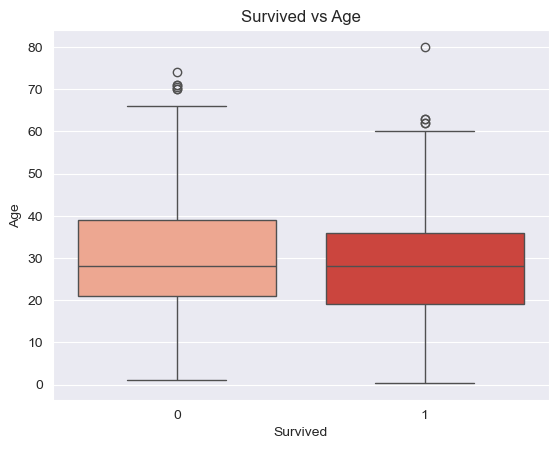

In [16]:
#age vs survived plot
sns.boxplot(x='Survived', y='Age', data=df,palette='Reds')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.title('Survived vs Age')
plt.show()

In [17]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

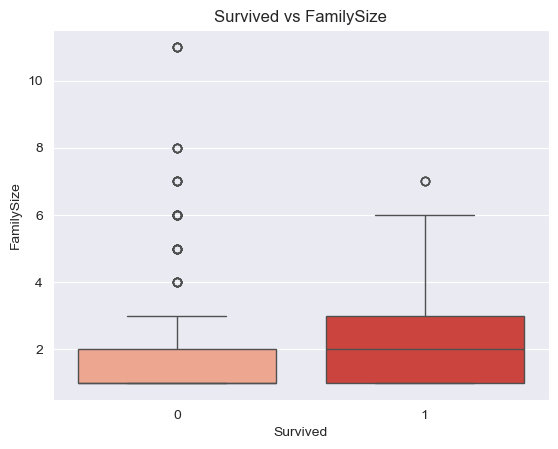

In [18]:
sns.boxplot(x='Survived', y='FamilySize', data=df,palette='Reds')
plt.xlabel('Survived')
plt.ylabel('FamilySize')
plt.title('Survived vs FamilySize')
plt.show()

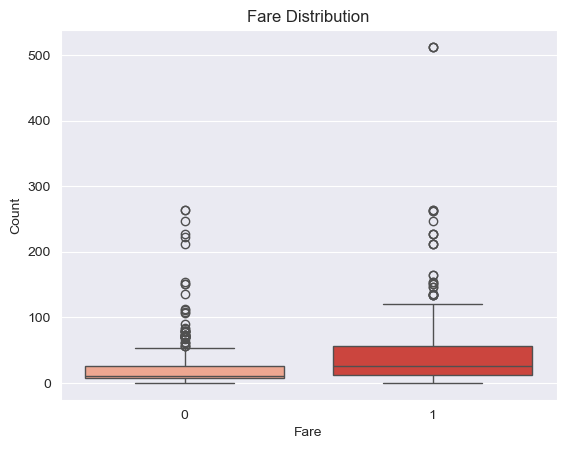

In [19]:
sns.boxplot(data=df,x='Survived',palette='Reds',y='Fare')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.title('Fare Distribution')
plt.show()

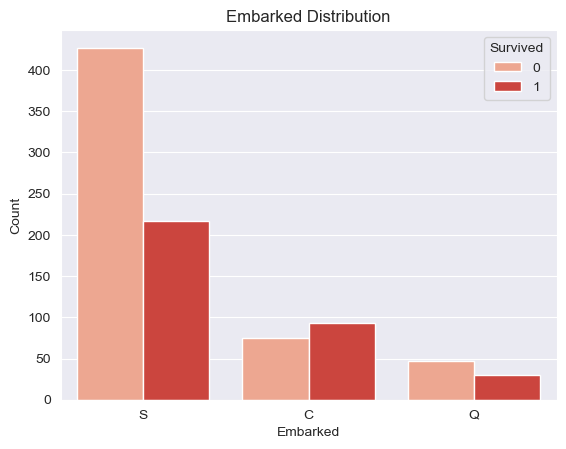

In [20]:
sns.countplot(data=df,x='Embarked',palette='Reds',hue='Survived')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.title('Embarked Distribution')
plt.show()

## PREPROCESSING AND FEATURE SELECTION

In [26]:
# df.drop(columns=['SibSp','Parch'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         714 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    889 non-null    object 
 6   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [27]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [28]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [29]:
num_col = [col for col in X_train.columns if X_train[col].dtype != 'O']
cat_col = [col for col in X_train.columns if X_train[col].dtype == 'O']

## handling missing values

In [30]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer.fit(X_train[num_col])
X_train[num_col] = imputer.transform(X_train[num_col])
X_test[num_col] = imputer.transform(X_test[num_col])

In [31]:
imputer_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imputer_cat.fit(X_train[cat_col])
X_train[cat_col] = imputer_cat.transform(X_train[cat_col])
X_test[cat_col] = imputer_cat.transform(X_test[cat_col])

In [32]:
X_train.isna().sum()

Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
FamilySize    0
dtype: int64

In [35]:
encoder = LabelEncoder()
encoder.fit(X_train['Sex'])
X_train['Sex'] = encoder.transform(X_train['Sex'])
X_test['Sex'] = encoder.transform(X_test['Sex'])

In [36]:
df_embarket_train = pd.get_dummies(X_train['Embarked'])
X_train = pd.concat([X_train,df_embarket_train],axis=1)

df_embarket_test = pd.get_dummies(X_test['Embarked'])
X_test = pd.concat([X_test,df_embarket_test],axis=1)

In [37]:
X_train = X_train.drop(columns=['Embarked'])
X_test = X_test.drop(columns=['Embarked'])
X_train['C']=X_train['C'].astype(int)
X_train['Q']=X_train['Q'].astype(int)
X_train['S']=X_train['S'].astype(int)


In [38]:
X_train.head()

,Pclass,Sex,Age,Fare,FamilySize,C,Q,S
486,1.0,0,35.0,90.000,2.0,0,0,1
238,2.0,1,19.0,10.500,1.0,0,0,1
722,2.0,1,34.0,13.000,1.0,0,0,1
184,3.0,0,4.0,22.025,3.0,0,0,1
56,2.0,0,21.0,10.500,1.0,0,0,1


## TRAIN THE MODEL

In [39]:
best_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42,learning_rate=1)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=1, n_estimators=100, random_state=42)

In [40]:
scores = cross_val_score(ada_model, X_train, y_train, cv=5,scoring='accuracy')
print('Cross-validation scores:', scores)
print('Mean accuracy:', scores.mean())

Cross-validation scores: [0.76119403 0.79104478 0.86567164 0.83458647 0.86466165]
Mean accuracy: 0.8234317136123892


In [41]:
y_pred_test = ada_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_test))

[[112  25]
 [ 24  62]]


In [42]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       137
           1       0.71      0.72      0.72        86

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223



## TUNING HYPARAMETERS TO GET THE CORRECT PREDICTION

In [43]:
grid_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2)],
}

model_tun = AdaBoostClassifier(random_state=42)

grid_search = GridSearchCV(estimator=model_tun, param_grid=grid_params,cv=5,scoring='accuracy')
grid_search.fit(X_train, y_train)


print('Best parameters:', grid_search.best_params_)
print('Best score:', grid_search.best_score_)

Best parameters: {'estimator': DecisionTreeClassifier(max_depth=2), 'learning_rate': 0.1, 'n_estimators': 100}
Best score: 0.8428122545168891


In [44]:
model_aft_tun = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100, random_state=42,learning_rate=1)

model_aft_tun.fit(X_train, y_train)

y_pred_test = model_aft_tun.predict(X_test)

print(confusion_matrix(y_test, y_pred_test))

print(classification_report(y_test, y_pred_test))

[[114  23]
 [ 35  51]]
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       137
           1       0.69      0.59      0.64        86

    accuracy                           0.74       223
   macro avg       0.73      0.71      0.72       223
weighted avg       0.74      0.74      0.74       223



Text(0.5, 1.0, 'Confusion Matrix')

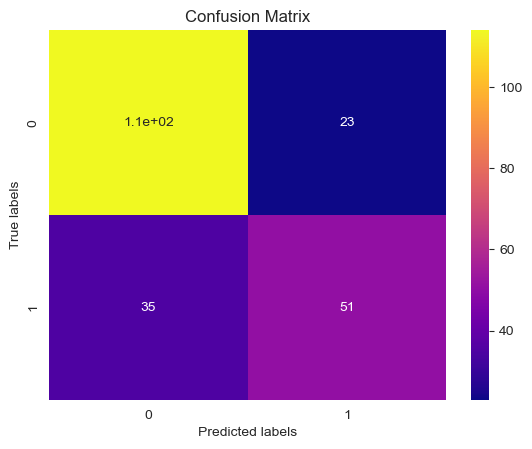

In [51]:
# predictions
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap='plasma')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')